In [5]:
!pip install torchvision

   ---------------------------------------- 0.0/4.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/4.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/4.1 MB ? eta -:--:--
   -- ------------------------------------- 0.3/4.1 MB ? eta -:--:--
   ----- ---------------------------------- 0.5/4.1 MB 1.8 MB/s eta 0:00:03
   ------------ --------------------------- 1.3/4.1 MB 2.4 MB/s eta 0:00:02
   --------------- ------------------------ 1.6/4.1 MB 2.6 MB/s eta 0:00:01
   -------------------- ------------------- 2.1/4.1 MB 2.3 MB/s eta 0:00:01
   ---------------------------- ----------- 2.9/4.1 MB 2.5 MB/s eta 0:00:01
   --------------------------------- ------ 3.4/4.1 MB 2.6 MB/s eta 0:00:01
   -------------------------------------- - 3.9/4.1 MB 2.5 MB/s eta 0:00:01
   ---------------------------------------- 4.1/4.1 MB 2.5 MB/s  0:00:02


In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(42)
np.random.seed(42)

In [7]:
tf = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
train_set = datasets.FashionMNIST(root="./data", train=True,  download=True, transform=tf)
val_set   = datasets.FashionMNIST(root="./data", train=False, download=True, transform=tf)
train_loader = DataLoader(train_set, batch_size=128, shuffle=True)
val_loader   = DataLoader(val_set,   batch_size=256, shuffle=False)

100%|██████████| 26.4M/26.4M [00:08<00:00, 2.95MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 196kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 2.53MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 2.66MB/s]


#### Task 1 — Train the Network

You will train one classifier on Fashion-MNIST. Everything you need is fully specified below.

The architecture. A four-layer fully-connected ReLU network with batch normalisation on the hidden layers and dropout on the two widest layers. Input is a flattened 28×28 grayscale image (784 features); output is 10 class logits (no softmax — CrossEntropyLoss includes it).

Step	Layer	Output shape	Notes
0	Input	(B, 1, 28, 28)	a Fashion-MNIST batch
1	Flatten()	(B, 784)	28·28 = 784 features
2	Linear(784, 256) → BatchNorm1d(256) → ReLU → Dropout(p=0.3)	(B, 256)	widest hidden layer
3	Linear(256, 128) → BatchNorm1d(128) → ReLU → Dropout(p=0.3)	(B, 128)	second hidden layer
4	Linear(128, 64) → BatchNorm1d(64) → ReLU	(B, 64)	third hidden layer (no dropout here — kept narrow on purpose)
5	Linear(64, 10)	(B, 10)	class logits
The training-time hyperparameters. Use exactly these values — no tuning, no comparisons, no extra variants.

Parameter	Value
Loss	nn.CrossEntropyLoss()
Optimiser	torch.optim.Adam with lr=1e-3, weight_decay=1e-4
LR schedule	torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
Epochs	15
Batch size	128 (already set in the DataLoaders above)
Random seed	42 (already set in the setup)
Device	"cuda" if available, otherwise "cpu"
What to do.

1şTranslate the architecture in the table into a PyTorch nn.Sequential (or a small nn.Module subclass — whichever you prefer) and move it to device. Print the model so the layers are visible in the notebook.

2.Build the canonical training loop. For each epoch:

- Set the model to train() mode, iterate over train_loader, and run the five-step inner loop (optimizer.zero_grad(), forward, loss, loss.backward(), optimizer.step()). Call scheduler.step() once at the end of the epoch.

- Set the model to eval() mode and, inside torch.no_grad(), compute the average loss and accuracy on both train_loader and val_loader.

- Append train_loss, val_loss, train_acc, val_acc to four Python lists.

3.Run the loop for 15 epochs. After training, plot two figures side by side: training and validation loss vs epoch, and training and validation accuracy vs epoch. Print the best validation accuracy and the epoch at which it occurred.

4.In a short markdown cell (2–3 sentences), describe what your curves look like — for example, does the model still improve at epoch 15, do training and validation loss stay close together, and what is your best validation accuracy. Validation accuracy is expected to land around 89–90% on this architecture; report whatever number you actually got.

In [9]:
model = nn.Sequential(

    nn.Flatten(),
    nn.Linear(784, 256),
    nn.BatchNorm1d(256),
    nn.ReLU(),
    nn.Dropout(0.3),

    nn.Linear(256, 128),
    nn.BatchNorm1d(128),
    nn.ReLU(),
    nn.Dropout(0.3),

    nn.Linear(128, 64),
    nn.BatchNorm1d(64),
    nn.ReLU(),

    nn.Linear(64, 10)

).to(device)

print(model)

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=256, bias=True)
  (2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (3): ReLU()
  (4): Dropout(p=0.3, inplace=False)
  (5): Linear(in_features=256, out_features=128, bias=True)
  (6): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (7): ReLU()
  (8): Dropout(p=0.3, inplace=False)
  (9): Linear(in_features=128, out_features=64, bias=True)
  (10): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (11): ReLU()
  (12): Linear(in_features=64, out_features=10, bias=True)
)


In [10]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(),lr=1e-3,weight_decay=1e-4)
epochs = 15

scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer,T_max=epochs)

In [11]:
train_losses = []
val_losses = []

train_accs = []
val_accs = []

In [12]:
def accuracy_fn(preds, labels):
    predicted_classes = preds.argmax(dim=1)
    correct = (predicted_classes == labels).sum().item()

    return correct / len(labels)

In [13]:
for epoch in range(epochs):

    # TRAIN MODE
    model.train()

    running_train_loss = 0
    running_train_acc = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        # 1. gradients sıfırlanır
        optimizer.zero_grad()

        # 2. forward
        outputs = model(images)

        # 3. loss
        loss = criterion(outputs, labels)

        # 4. backward
        loss.backward()

        # 5. weights update
        optimizer.step()

        running_train_loss += loss.item()

        running_train_acc += accuracy_fn(outputs, labels)

    scheduler.step()

    avg_train_loss = running_train_loss / len(train_loader)
    avg_train_acc = running_train_acc / len(train_loader)

    # EVALUATION MODE
    model.eval()

    running_val_loss = 0
    running_val_acc = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_val_loss += loss.item()

            running_val_acc += accuracy_fn(outputs, labels)

    avg_val_loss = running_val_loss / len(val_loader)
    avg_val_acc = running_val_acc / len(val_loader)

    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)

    train_accs.append(avg_train_acc)
    val_accs.append(avg_val_acc)

    print(f"Epoch [{epoch+1}/{epochs}]")
    print(f"Train Loss: {avg_train_loss:.4f} | Train Acc: {avg_train_acc:.4f}")
    print(f"Val Loss: {avg_val_loss:.4f} | Val Acc: {avg_val_acc:.4f}")

Epoch [1/15]
Train Loss: 0.5868 | Train Acc: 0.8115
Val Loss: 0.4016 | Val Acc: 0.8521
Epoch [2/15]
Train Loss: 0.4031 | Train Acc: 0.8549
Val Loss: 0.3738 | Val Acc: 0.8647
Epoch [3/15]
Train Loss: 0.3690 | Train Acc: 0.8661
Val Loss: 0.3576 | Val Acc: 0.8665
Epoch [4/15]
Train Loss: 0.3454 | Train Acc: 0.8736
Val Loss: 0.3470 | Val Acc: 0.8709
Epoch [5/15]
Train Loss: 0.3276 | Train Acc: 0.8786
Val Loss: 0.3374 | Val Acc: 0.8766
Epoch [6/15]
Train Loss: 0.3090 | Train Acc: 0.8875
Val Loss: 0.3176 | Val Acc: 0.8829
Epoch [7/15]
Train Loss: 0.2964 | Train Acc: 0.8902
Val Loss: 0.3156 | Val Acc: 0.8860
Epoch [8/15]
Train Loss: 0.2823 | Train Acc: 0.8952
Val Loss: 0.3163 | Val Acc: 0.8827
Epoch [9/15]
Train Loss: 0.2688 | Train Acc: 0.9001
Val Loss: 0.3048 | Val Acc: 0.8907
Epoch [10/15]
Train Loss: 0.2573 | Train Acc: 0.9053
Val Loss: 0.2934 | Val Acc: 0.8952
Epoch [11/15]
Train Loss: 0.2443 | Train Acc: 0.9098
Val Loss: 0.2945 | Val Acc: 0.8921
Epoch [12/15]
Train Loss: 0.2345 | Train 

In [14]:
best_acc = max(val_accs)
best_epoch = val_accs.index(best_acc) + 1

print(f"Best Validation Accuracy: {best_acc:.4f}")
print(f"Best Epoch: {best_epoch}")

Best Validation Accuracy: 0.8976
Best Epoch: 14


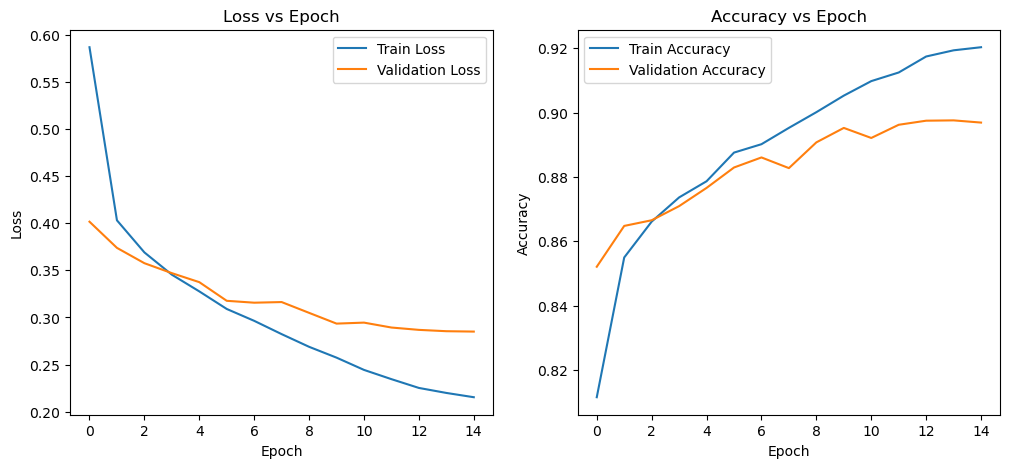

In [15]:
plt.figure(figsize=(12,5))

# LOSS
plt.subplot(1,2,1)

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("Loss vs Epoch")

plt.legend()

# ACCURACY
plt.subplot(1,2,2)

plt.plot(train_accs, label="Train Accuracy")
plt.plot(val_accs, label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title("Accuracy vs Epoch")

plt.legend()

plt.show()

The training and validation loss both decreased over the epochs, showing that the model learned effectively during training. The validation loss stayed relatively close to the training loss, although a small gap appeared in later epochs, suggesting mild overfitting.

The training and validation accuracy steadily improved throughout training. Validation accuracy reached nearly 90%, while training accuracy continued increasing until the final epoch. The best validation accuracy achieved was approximately 89.8%.